In [1]:
import sys
if 'google.colab' in sys.modules:
    !wget https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week08_pomdp/atari_util.py
    !wget https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/week08_pomdp/env_pool.py

    !pip install -q gymnasium[atari,accept-rom-license]

    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete
# If you are running on a server, launch xvfb to record game videos
# Please make sure you have xvfb installed
import os
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'


Starting virtual X frame buffer: Xvfb../xvfb: line 24: start-stop-daemon: command not found
.


In [2]:
import numpy as np
from IPython.core import display
import matplotlib.pyplot as plt
%matplotlib inline


### Kung-Fu, recurrent style

In this notebook we'll once again train RL agent for for Atari [KungFuMaster](https://gymnasium.farama.org/environments/atari/kung_fu_master/), this time using recurrent neural networks.

![img](https://upload.wikimedia.org/wikipedia/en/6/66/Kung_fu_master_mame.png)

In [4]:
!pip install "gymnasium[atari,accept-rom-license]"



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import gymnasium as gym
import ale_py
from atari_util import PreprocessAtari

gym.register_envs(ale_py)

def make_env():
    env = gym.make("ALE/KungFuMaster-v5", 
                   frameskip=4,
                   repeat_action_probability=0.0,
                   render_mode="rgb_array")
    
    env = PreprocessAtari(env, height=42, width=42,
                          crop=lambda img: img[60:-30, 15:],
                          color=False, n_frames=1)
    return env


env = make_env()

obs_shape = env.observation_space.shape
n_actions = env.action_space.n

print("Observation shape:", obs_shape)
print("Num actions:", n_actions)
print("Action names:", env.unwrapped.get_action_meanings())


Observation shape: (1, 42, 42)
Num actions: 14
Action names: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'DOWNRIGHT', 'DOWNLEFT', 'RIGHTFIRE', 'LEFTFIRE', 'DOWNFIRE', 'UPRIGHTFIRE', 'UPLEFTFIRE', 'DOWNRIGHTFIRE', 'DOWNLEFTFIRE']


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


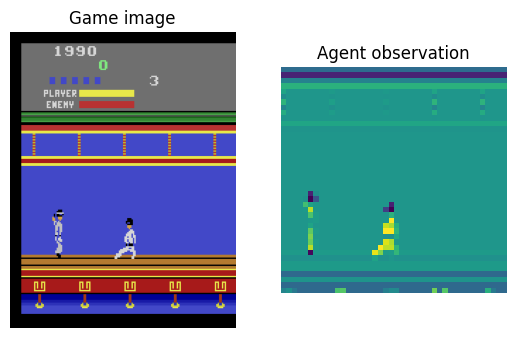

In [ ]:
s, _ = env.reset()
for _ in range(100):
    s, _, _, _, _ = env.step(env.action_space.sample())

plt.subplot(121)
plt.title('Game image')
plt.axis('off')
plt.imshow(env.render())
# plt.show()
plt.subplot(122)
plt.title('Agent observation')
plt.axis('off')
plt.imshow(s.reshape([42, 42]))

plt.show()


### POMDP setting

The Atari game we're working with is actually a POMDP: your agent needs to know timing at which enemies spawn and move, but cannot do so unless it has some memory. 

Let's design another agent that has a recurrent neural net memory to solve this. Here's a sketch.

![img](img1.jpg)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device(
    'cuda' if torch.cuda.is_available() 
    else 'mps' if torch.mps.is_available() 
    else 'cpu'
    )


print(f"Using {device} device")


Using mps device


In [ ]:
class SimpleRecurrentAgent(nn.Module):
    def __init__(self, obs_shape, n_actions, reuse=False):
        """A simple actor-critic agent"""
        super(self.__class__, self).__init__()

        self.convs = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2),
            nn.ELU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=2),
            nn.ELU(),
            nn.Conv2d(32, 32, kernel_size=3, stride=2),
            nn.ELU(),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU()
        )

        self.rnn = nn.LSTMCell(128, 128)

        self.logits = nn.Linear(128, n_actions)
        self.state_value = nn.Linear(128, 1)

    def forward(self, prev_state: tuple[torch.Tensor, torch.Tensor], obs_t: torch.Tensor):
        """
        Takes agent's previous hidden state and a new observation,
        returns a new hidden state and whatever the agent needs to learn
        """

        # Apply the whole neural net for one step here.
        # See docs on self.rnn(...).
        # The recurrent cell should take the last feedforward dense layer as input.
        obs_state = self.convs(obs_t)
        new_state = self.rnn(obs_state, prev_state)
        logits = self.logits(new_state[0])
        state_value = self.state_value(new_state[0])

        return new_state, (logits, state_value)

    def get_initial_state(self, batch_size):
        """Return a list of agent memory states at game start. Each state is a np array of shape [batch_size, ...]"""
        return torch.zeros((batch_size, 128), device=device), torch.zeros((batch_size, 128), device=device)

    def sample_actions(self, agent_outputs):
        """pick actions given numeric agent outputs (np arrays)"""
        logits, state_values = agent_outputs
        probs = F.softmax(logits, dim=-1)
        return torch.multinomial(probs, 1)[:, 0].cpu().numpy()

    def step(self, prev_state, obs_t):
        """ like forward, but obs_t is a numpy array """
        obs_t = torch.tensor(np.asarray(obs_t), dtype=torch.float32, device=device)
        (h, c), (l, s) = self.forward(prev_state, obs_t)
        return (h.detach(), c.detach()), (l.detach(), s.detach())


In [8]:
n_parallel_games = 5
gamma = 0.99

agent = SimpleRecurrentAgent(obs_shape, n_actions).to(device)


In [9]:
state = [env.reset()[0]]
_, (logits, value) = agent.step(agent.get_initial_state(1), state)
print("action logits:\n", logits)
print("state values:\n", value)


action logits:
 tensor([[ 0.0250, -0.0173, -0.0353,  0.0141,  0.0332, -0.0561,  0.0207, -0.0191,
          0.0131,  0.0686, -0.0319, -0.0327,  0.0678,  0.0315]],
       device='mps:0')
state values:
 tensor([[-0.0595]], device='mps:0')


### Let's play!
Let's build a function that measures agent's average reward.

In [10]:
def evaluate(agent, env, n_games=1):
    """Plays an entire game start to end, returns session rewards."""

    game_rewards = []
    for _ in range(n_games):
        # initial observation and memory
        observation, _ = env.reset()
        prev_memories = agent.get_initial_state(1)

        total_reward = 0
        while True:
            new_memories, readouts = agent.step(
                prev_memories, observation[None, ...])
            action = agent.sample_actions(readouts)

            observation, reward, terminated, truncated, info = env.step(action[0])

            total_reward += reward
            prev_memories = new_memories
            if terminated or truncated:
                break

        game_rewards.append(total_reward)
    return game_rewards


In [11]:
from gymnasium.wrappers import RecordVideo

with make_env() as record_env, RecordVideo(record_env, video_folder="videos") as env_monitor:
    rewards = evaluate(agent, env_monitor, n_games=3)

print(rewards)


/Users/timofejbulgakov/.pyenv/versions/PracticalRL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/timofejbulgakov/VSCodeProjects/Practical_RL/week08_pomdp/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


[400.0, 200.0, 300.0]


In [22]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))


### Training on parallel games

We introduce a class called EnvPool - it's a tool that handles multiple environments for you. Here's how it works:
![img](img2.jpg)

We gonna train our agent on a thing called __rollouts:__
![img](img3.jpg)

A rollout is just a sequence of T observations, actions and rewards that agent took consequently.
* First __s0__ is not necessarily initial state for the environment
* Final state is not necessarily terminal
* We sample several parallel rollouts for efficiency

In [12]:
# for each of n_parallel_games, take 10 steps
from env_pool import EnvPool

pool = EnvPool(agent, make_env, n_parallel_games)
rollout_obs, rollout_actions, rollout_rewards, rollout_mask = pool.interact(10)


In [13]:
print("Actions shape:", rollout_actions.shape)
print("Rewards shape:", rollout_rewards.shape)
print("Mask shape:", rollout_mask.shape)
print("Observations shape: ", rollout_obs.shape)


Actions shape: (5, 10)
Rewards shape: (5, 10)
Mask shape: (5, 10)
Observations shape:  (5, 10, 1, 42, 42)


# Actor-critic objective

Here we define a loss function that uses rollout above to train advantage actor-critic agent.


Our loss consists of three components:

* __The policy "loss"__
 $$ \hat J = {1 \over T} \cdot \sum_t { \log \pi(a_t | s_t) } \cdot A_{const}(s,a) $$
  * This function has no meaning in and of itself, but it was built such that
  * $ \nabla \hat J = {1 \over N} \cdot \sum_t { \nabla \log \pi(a_t | s_t) } \cdot A(s,a) \approx \nabla E_{s, a \sim \pi} R(s,a) $
  * Therefore if we __maximize__ J_hat with gradient descent we will maximize expected reward
  
  
* __The value "loss"__
  $$ L_{td} = {1 \over T} \cdot \sum_t { [r + \gamma \cdot V_{const}(s_{t+1}) - V(s_t)] ^ 2 }$$
  * Ye Olde TD_loss from q-learning and alike
  * If we minimize this loss, V(s) will converge to $V_\pi(s) = E_{a \sim \pi(a | s)} R(s,a) $


* __Entropy Regularizer__
  $$ H = - {1 \over T} \sum_t \sum_a {\pi(a|s_t) \cdot \log \pi (a|s_t)}$$
  * If we __maximize__ entropy we discourage agent from predicting zero probability to actions
  prematurely (a.k.a. exploration)
  
  
So we optimize a linear combination of $L_{td}$ $- \hat J$, $-H$
  
```

```

```

```

```

```


__One more thing:__ since we train on T-step rollouts, we can use N-step formula for advantage for free:
  * At the last step, $A(s_t,a_t) = r(s_t, a_t) + \gamma \cdot V(s_{t+1}) - V(s) $
  * One step earlier, $A(s_t,a_t) = r(s_t, a_t) + \gamma \cdot r(s_{t+1}, a_{t+1}) + \gamma ^ 2 \cdot V(s_{t+2}) - V(s) $
  * Et cetera, et cetera. This way agent starts training much faster since it's estimate of A(s,a) depends less on his (imperfect) value function and more on actual rewards. There's also a [nice generalization](https://arxiv.org/abs/1506.02438) of this.


__Note:__ it's also a good idea to scale rollout_len up to learn longer sequences. You may wish set it to >=20 or to start at 10 and then scale up as time passes.

In [47]:
_to_numpy = lambda x : x.detach().cpu().numpy()
opt = torch.optim.Adam(agent.parameters())

def compute_cummulitive_returns(state_values, rewards, is_not_done_next, gamma):
    cummulitive_return = state_values[:, -1].detach()
    cummulitive_returns = []
    
    for t in range(rewards.shape[1]):
        cummulitive_return = rewards[:, -t] + gamma * is_not_done_next[:, -t] * cummulitive_return
        cummulitive_returns.append(cummulitive_return)

    return torch.stack(cummulitive_returns[::-1], dim=1)

def agent_predict(states, memory):
    logits = []  # append logit sequence here
    state_values = []  # append state values here

    for t in range(states.shape[1]):
        obs_t = states[:, t]

        # use agent to comute logits_t and state values_t.
        # append them to logits and state_values array
        memory, (logits_t, values_t) = agent(memory, obs_t)

        logits.append(logits_t)
        state_values.append(values_t)

    return torch.stack(logits, dim=1), torch.stack(state_values, dim=1).squeeze(-1)
    

def train_on_rollout(states, actions, rewards, is_not_done, prev_memory_states, 
                     gamma=0.99, entropy_coef=0.01, max_grad_norm=10., reward_norm=100.0):
    """
    Takes a sequence of states, actions and rewards produced by generate_session.
    Updates agent's weights by following the policy gradient above.
    Please use Adam optimizer with default parameters.
    """

    # shape: [batch_size, time, c, h, w]
    states = torch.tensor(np.asarray(states), dtype=torch.float32, device=device)
    actions = torch.tensor(np.array(actions), dtype=torch.int64, device=device)  # shape: [batch_size, time]
    rewards = torch.tensor(np.array(rewards), dtype=torch.float32, device=device)  # shape: [batch_size, time]
    is_not_done = torch.tensor(np.array(is_not_done), dtype=torch.float32, device=device)  # shape: [batch_size, time]

    # predict logits, probas and log-probas using an agent.
    memory = [m.detach() for m in prev_memory_states]

    logits, state_values = agent_predict(states, memory)
    
    probas = F.softmax(logits, dim=2)
    logprobas = F.log_softmax(logits, dim=2)

    # select log-probabilities for chosen actions, log pi(a_i|s_i)
    actions_one_hot = F.one_hot(actions, n_actions).view(
        actions.shape[0], actions.shape[1], n_actions)
    logprobas_for_actions = torch.sum(logprobas * actions_one_hot, dim=-1)

    values_t = state_values[:, :-1]
    rewards_t = rewards[:, :-1] / reward_norm

    is_not_done_t = is_not_done[:, :-1]
    is_not_done_next = is_not_done[:, 1:]

    returns = compute_cummulitive_returns(state_values, rewards_t, is_not_done_next, gamma)
    # target = rewards_t + gamma * is_not_done_next * values_next
    advantage = returns - values_t

    n = is_not_done_t.sum().clamp_min(1)

    J_hat = logprobas_for_actions[:, :-1] * advantage.detach() * is_not_done_t
    J_hat = J_hat.sum() / n

    value_loss = is_not_done_t * (returns.detach() - values_t) ** 2
    value_loss = value_loss.sum() / n

    entropy = -(probas[:, :-1] * logprobas[:, :-1]).sum(dim=-1)
    entropy = (entropy * is_not_done_t).sum() / n

    loss = -J_hat + value_loss - entropy_coef * entropy

    # Gradient descent step
    opt.zero_grad()
    loss.backward()
    grad_norm = nn.utils.clip_grad_norm_(agent.parameters(), max_norm=max_grad_norm)
    opt.step()

    return _to_numpy(loss), _to_numpy(entropy), _to_numpy(grad_norm)


In [48]:
# let's test it
memory = list(pool.prev_memory_states)
rollout_obs, rollout_actions, rollout_rewards, rollout_mask = pool.interact(10)

train_on_rollout(rollout_obs, rollout_actions,
                 rollout_rewards, rollout_mask, memory)


(array(-0.18944566, dtype=float32),
 array(2.0817978, dtype=float32),
 array(4.7166085, dtype=float32))

# Train 

just run train step and see if agent learns any better

In [ ]:
from IPython.display import clear_output
from tqdm import trange
from pandas import DataFrame
moving_average = lambda x, **kw: DataFrame({
    'x': np.asarray(x)
    }).x.ewm(**kw).mean().values




In [57]:
from env_pool import EnvPool

device = 'cpu'

agent = SimpleRecurrentAgent(obs_shape, n_actions).to(device)

opt = torch.optim.Adam(agent.parameters(), lr=4e-5)
pool = EnvPool(agent, make_env, n_parallel_games)



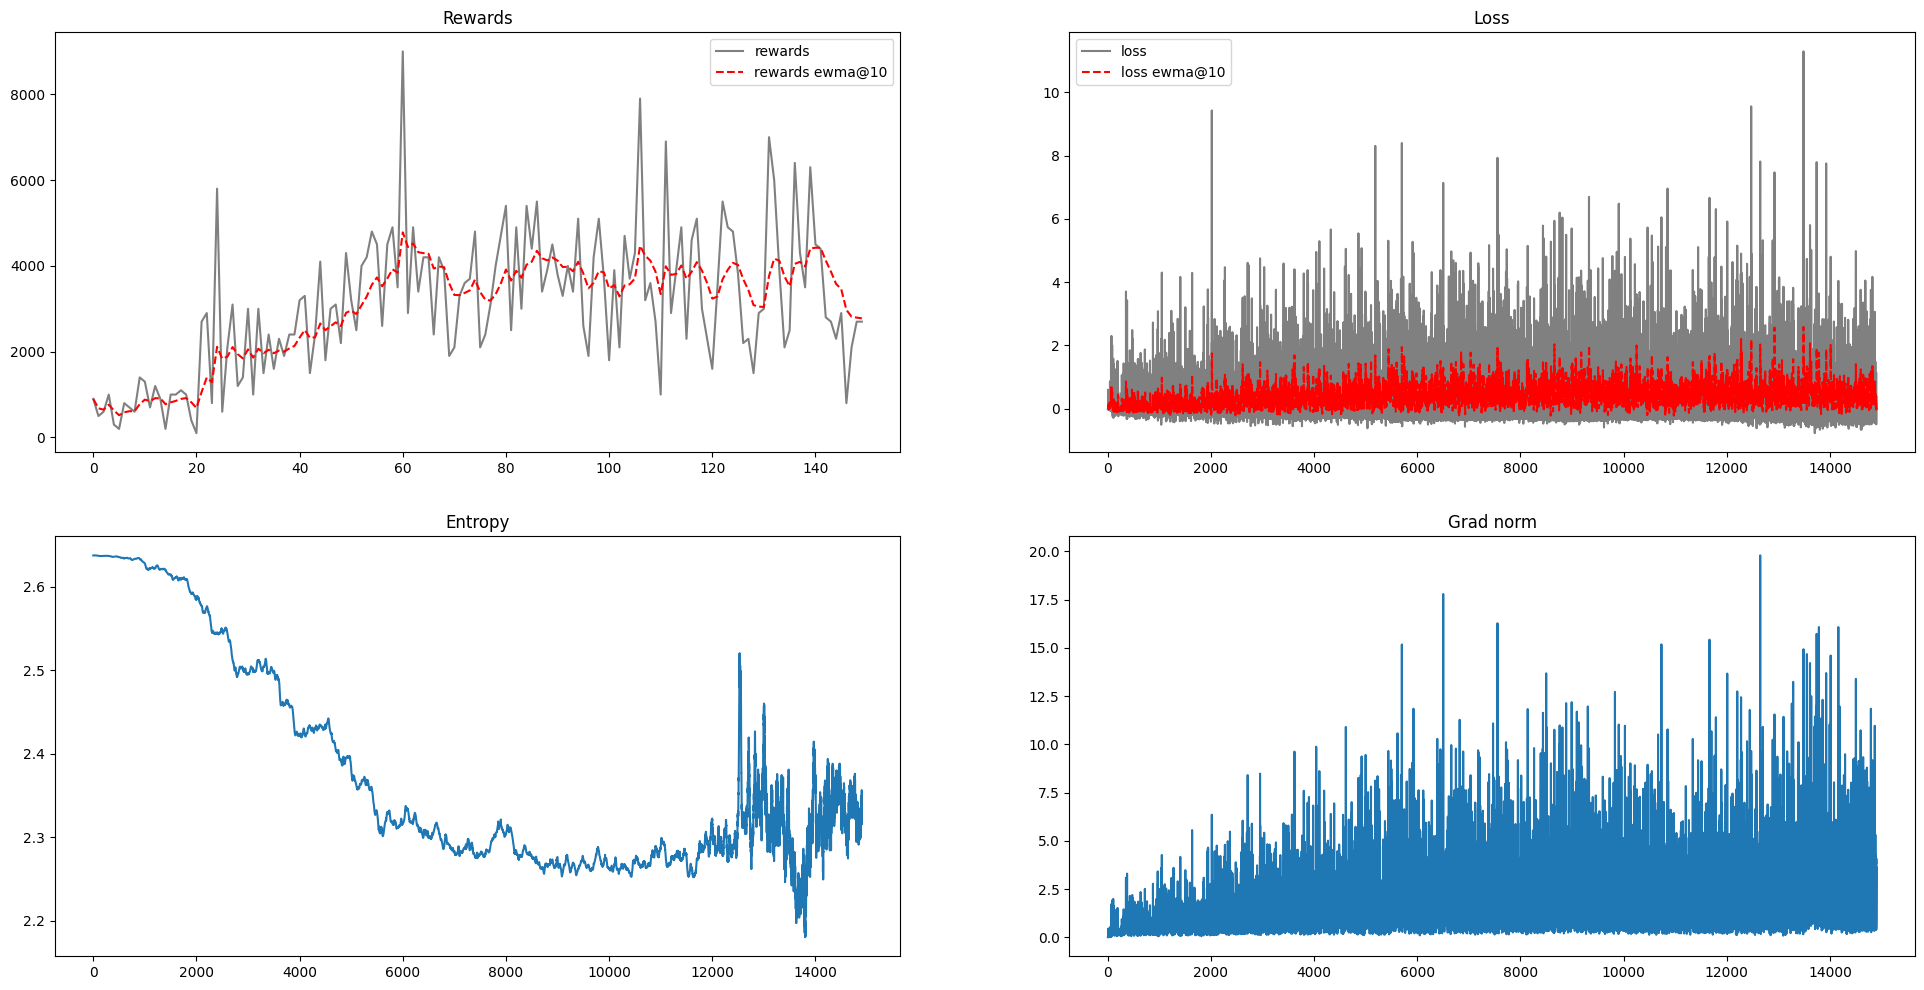

100%|██████████| 15000/15000 [22:49<00:00, 10.96it/s]


In [58]:
loss_history = []
entropy_history = []
rewards_history = []
grad_norm_history = []

epoch_steps = 15000
clear_output(True)

for i in trange(epoch_steps):
    memory = list(pool.prev_memory_states)
    rollout_obs, rollout_actions, rollout_rewards, rollout_mask = pool.interact(20)
    loss, entropy, grad_norm =  train_on_rollout(rollout_obs, rollout_actions,
                     rollout_rewards, rollout_mask, memory, 
                     max_grad_norm=2.0
                     )
    
    loss_history.append(loss.item())
    entropy_history.append(entropy.item())
    grad_norm_history.append(grad_norm.item())

    if i % 100 == 0:
        rewards_history.append(np.mean(evaluate(agent, env, n_games=1)))
        
        clear_output(True)
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(24, 12))
        
        ax1.set_title("Rewards")
        ax1.plot(rewards_history, label='rewards', color='gray')
        ax1.plot(moving_average(rewards_history, span=10), 
                 label='rewards ewma@10', linestyle='--', color="red"
                 )
        ax1.legend()

        ax2.set_title("Loss")
        ax2.plot(loss_history, label='loss', color='gray')
        ax2.plot(moving_average(loss_history, span=10), 
                 label='loss ewma@10', linestyle='--', color="red"
                 )
        ax2.legend()
        
        ax3.set_title("Entropy")
        ax3.plot(entropy_history)

        ax4.set_title("Grad norm")
        ax4.plot(grad_norm_history)
        
        plt.show()

        if rewards_history[-1] >= 10000:
            print("Your agent has just passed the minimum homework threshold")
            break


Relax and grab some refreshments while your agent is locked in an infinite loop of violence and death.

__How to interpret plots:__

The session reward is the easy thing: it should in general go up over time, but it's okay if it fluctuates ~~like crazy~~. It's also OK if it reward doesn't increase substantially before some 10k initial steps. However, if reward reaches zero and doesn't seem to get up over 2-3 evaluations, there's something wrong happening.


Since we use a policy-based method, we also keep track of __policy entropy__ - the same one you used as a regularizer. The only important thing about it is that your entropy shouldn't drop too low (`< 0.1`) before your agent gets the yellow belt. Or at least it can drop there, but _it shouldn't stay there for long_.

If it does, the culprit is likely:
* Some bug in entropy computation. Remember that it is $ - \sum p(a_i) \cdot log p(a_i) $
* Your agent architecture converges too fast. Increase entropy coefficient in actor loss. 
* Gradient explosion - just [clip gradients](https://stackoverflow.com/a/56069467) and maybe use a smaller network
* Us. Or PyTorch developers. Or aliens. Or lizardfolk. Contact us on forums before it's too late!

If you're debugging, just run `logits, values = agent.step(batch_states)` and manually look into logits and values. This will reveal the problem 9 times out of 10: you'll likely see some NaNs or insanely large numbers or zeros. Try to catch the moment when this happens for the first time and investigate from there.

### "Final" evaluation

In [59]:
from gymnasium.wrappers import RecordVideo

with make_env() as record_env, RecordVideo(record_env, video_folder="videos") as env_monitor:
    final_rewards = evaluate(agent, env_monitor, n_games=20)

print("Final mean reward", np.mean(final_rewards))


/Users/timofejbulgakov/.pyenv/versions/PracticalRL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /Users/timofejbulgakov/VSCodeProjects/Practical_RL/week08_pomdp/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Final mean reward 3800.0


In [60]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path('videos').iterdir() if s.suffix == '.mp4'])
video_path = video_paths[-1]  # You can also try other indices

if 'google.colab' in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open('rb') as fp:
        mp4 = fp.read()
    data_url = 'data:video/mp4;base64,' + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML("""
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(data_url))
